# BANOS Tutorial — Python

**BANOS** (Behavior ANnOtation Score) evaluates how well algorithmic annotations match human ground truth for animal behavior studies.

This tutorial has two sections:
1. **Classic BANOS usage** — score annotations with `banos.score()`, interpret metrics
2. **Frame-based F1 vs BANOS** — why BANOS differs from CalMS21 frame F1, and why intentionally

Dataset: CalMS21-derived, 10 recordings, behaviors: `attack`, `investigation`, `mount` (dropping `other`).

---
## Section 1 — Classic BANOS Usage

### 1.1 Setup

In [1]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import banos

print(f"banos version: {banos.__version__}")

DATASET = Path("../data/dataset_human_vs_human")
BEHAVIORS = ["attack", "investigation", "mount"]

banos version: 0.2.0


### 1.2 Single Recording

Recording_1, behaviors `attack`/`investigation`/`mount` (dropping `other`).

> **Note (v0.2.0 absent-behavior rule):**  
> - GT has no bouts AND machine predicts nothing → all metrics = **1.0** (correct absence)  
> - GT has no bouts BUT machine predicts bouts → all metrics = **0.0** (false detection)

In [2]:
pred = pd.read_csv(DATASET / "Recording_1" / "humanAnnotation_2.csv")[BEHAVIORS]
gt   = pd.read_csv(DATASET / "Recording_1" / "humanAnnotation_1.csv")[BEHAVIORS]

print(f"Frames: {len(pred)}  |  Behaviors: {BEHAVIORS}")
print("GT bouts per behavior:")
for b in BEHAVIORS:
    n_bouts = (gt[b].diff().fillna(gt[b]) == 1).sum()
    print(f"  {b}: {n_bouts} bouts")

Frames: 19307  |  Behaviors: ['attack', 'investigation', 'mount']
GT bouts per behavior:
  attack: 0 bouts
  investigation: 49 bouts
  mount: 30 bouts


In [3]:
metrics = banos.score(pred, gt)

metrics_df = pd.DataFrame(metrics).T.rename(columns={"f1_score": "da (F1)"})
print("Per-behavior metrics — Recording 1")
print(metrics_df.round(4).to_string())

Per-behavior metrics — Recording 1
               precision  recall  da (F1)      so      tp      ic
attack               1.0  1.0000   1.0000  1.0000  1.0000  1.0000
investigation        0.8  0.7347   0.7660  0.5444  0.0846  0.9829
mount                1.0  0.5333   0.6957  0.7333  0.0785  0.9909


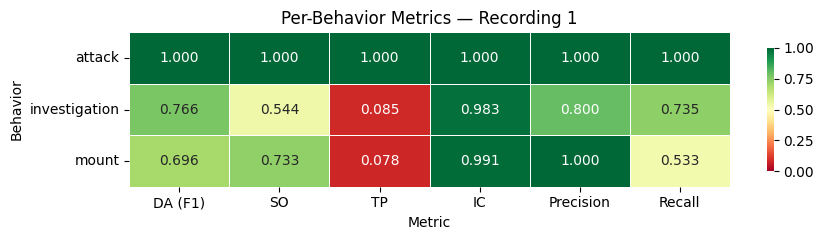

In [4]:
fig, ax = plt.subplots(figsize=(9, 2.5))
plot_df = pd.DataFrame(metrics).T[["f1_score", "so", "tp", "ic", "precision", "recall"]]
plot_df.columns = ["DA (F1)", "SO", "TP", "IC", "Precision", "Recall"]
sns.heatmap(
    plot_df.astype(float),
    annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1,
    ax=ax, linewidths=0.5, cbar_kws={"shrink": 0.8},
)
ax.set_title("Per-Behavior Metrics — Recording 1")
ax.set_xlabel("Metric")
ax.set_ylabel("Behavior")
plt.tight_layout()
plt.show()

### 1.3 Multi-Recording Batch

Pass a dict of `{name: (pred, gt)}` — returns `(group_metrics, overall_metrics)`.

In [5]:
data = {}
for n in range(1, 11):
    rec_dir = DATASET / f"Recording_{n}"
    p = pd.read_csv(rec_dir / "humanAnnotation_2.csv")[BEHAVIORS]
    g = pd.read_csv(rec_dir / "humanAnnotation_1.csv")[BEHAVIORS]
    data[f"Recording_{n}"] = (p, g)

group_metrics, overall_metrics = banos.score(data)

print("Overall metrics — 10 recordings (nanmean across behaviors and recordings)")
for metric, value in overall_metrics.items():
    v = f"{value:.4f}" if value is not None and not math.isnan(value) else "NaN"
    print(f"  {metric:<12} {v}")

Overall metrics — 10 recordings (nanmean across behaviors and recordings)
  precision    0.9355
  recall       0.6759
  f1_score     0.7745
  so           0.6980
  tp           0.3381
  ic           0.9948


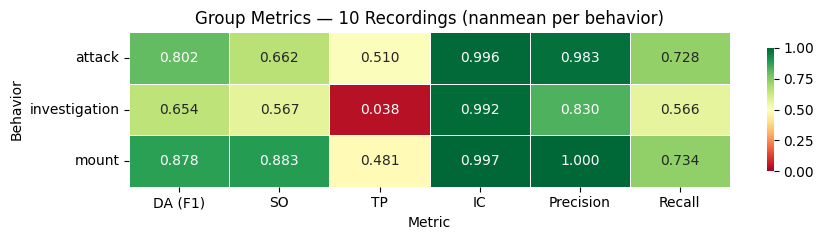

In [6]:
group_df = pd.DataFrame(group_metrics).T[["f1_score", "so", "tp", "ic", "precision", "recall"]]
group_df.columns = ["DA (F1)", "SO", "TP", "IC", "Precision", "Recall"]

fig, ax = plt.subplots(figsize=(9, 2.5))
sns.heatmap(
    group_df.astype(float),
    annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1,
    ax=ax, linewidths=0.5, cbar_kws={"shrink": 0.8},
)
ax.set_title("Group Metrics — 10 Recordings (nanmean per behavior)")
ax.set_xlabel("Metric")
ax.set_ylabel("Behavior")
plt.tight_layout()
plt.show()

### 1.4 Metric Explanations

| Metric | Full name | What it captures |
|--------|-----------|------------------|
| **DA** | Detection Accuracy (F1) | Bout-level F1 — did the system find the right bouts? |
| **SO** | Segment Overlap | Temporal IoU — how well do detected bouts overlap GT? |
| **TP** | Temporal Precision | Are bout boundaries (start/end frames) accurate? |
| **IC** | Intra-bout Continuity | Is each detected bout clean, without label fragmentation? |

**Absent-behavior rule (v0.2.0):**
- GT has no bouts **and** machine predicts nothing → all metrics = **1.0** (correct absence)  
- GT has no bouts **but** machine predicts bouts → all metrics = **0.0** (false detection)

---
## Section 2 — Frame-based F1 vs BANOS

### 2a. Frame-based F1: our implementation

We compute per-recording frame F1 for each behavior, macro-average across behaviors, then mean across recordings.

Absent-behavior scoring (explicit):
- GT=0 bouts and machine=0 bouts → **1.0** (correct absence)  
- GT=0 bouts and machine has bouts → **0.0** (false detection)

In [7]:
def frame_f1(pred_col, gt_col):
    """Frame-level F1 with explicit absent-behavior scoring.

    GT=0 bouts and machine=0 bouts -> 1.0 (correct absence)
    GT=0 bouts and machine has bouts -> 0.0 (false detection)
    Otherwise: standard precision/recall/F1.
    """
    if gt_col.sum() == 0 and pred_col.sum() == 0:
        return 1.0
    if gt_col.sum() == 0 and pred_col.sum() > 0:
        return 0.0
    tp = ((pred_col == 1) & (gt_col == 1)).sum()
    fp = ((pred_col == 1) & (gt_col == 0)).sum()
    fn = ((pred_col == 0) & (gt_col == 1)).sum()
    p  = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
    r  = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
    return 2*p*r/(p+r) if (p+r) > 0 else float("nan")


# Per-recording F1 per behavior, then macro-average, then mean across recordings
per_rec_f1 = []
for rec_name, (p, g) in data.items():
    f1s = [frame_f1(p[b].values, g[b].values) for b in BEHAVIORS]
    per_rec_f1.append(np.nanmean(f1s))

frame_f1_score = np.nanmean(per_rec_f1)
print(f"Frame-based F1: {frame_f1_score:.3f}")  

Frame-based F1: 0.815


### 2b. BANOS metrics: same recordings, same behaviors

In [9]:
group_metrics_all, overall_metrics_all = banos.score(data)

banos_da = overall_metrics_all["f1_score"]
banos_so = overall_metrics_all["so"]
banos_tp = overall_metrics_all["tp"]
banos_ic = overall_metrics_all["ic"]

print(f"BANOS DA (F1): {banos_da:.3f}")
print(f"BANOS SO:      {banos_so:.3f}")
print(f"BANOS TP:      {banos_tp:.3f}")
print(f"BANOS IC:      {banos_ic:.3f}")

BANOS DA (F1): 0.774
BANOS SO:      0.698
BANOS TP:      0.338
BANOS IC:      0.995


### 2c. Side-by-side comparison

In [10]:
comparison = [
    ("Frame-based F1", frame_f1_score, "Frame overlap; correct absence = 1"),
    ("BANOS DA (F1)",  banos_da,       "Bout-level detection (did system find right bouts?)"),
    ("BANOS SO",       banos_so,       "Temporal quality of overlapping bouts"),
    ("BANOS TP",       banos_tp,       "Boundary precision"),
    ("BANOS IC",       banos_ic,       "Label stability within detected bouts"),
]

print(f'{"Metric":<20} {"Value":>7}  What it captures')
print("-" * 70)
for name, val, desc in comparison:
    v = f"{val:.3f}" if val is not None and not math.isnan(val) else "NaN"
    print(f"{name:<20} {v:>7}  {desc}")

Metric                 Value  What it captures
----------------------------------------------------------------------
Frame-based F1         0.815  Frame overlap; correct absence = 1
BANOS DA (F1)          0.774  Bout-level detection (did system find right bouts?)
BANOS SO               0.698  Temporal quality of overlapping bouts
BANOS TP               0.338  Boundary precision
BANOS IC               0.995  Label stability within detected bouts


### 2d. Why our approach differs from CalMS21 — and why intentionally

**CalMS21 official frame-based F1 (Task 1):**
- Pool all frames from all recordings → one global F1 per behavior
- No explicit absent-behavior handling (relies on pooling — behaviors appear somewhere in the full dataset)
- Macro-average across 3 behaviors (attack/investigation/mount)

**Our approach differs in two ways:**

1. **Per-recording then averaged**: we treat each recording equally; CalMS21 weights by recording length. Per-recording aggregation preserves recording-level variability.

2. **Explicit absent-behavior scoring**: we explicitly reward correct absence (score 1) and penalize false detection (score 0). CalMS21’s pooled approach implicitly handles this by having behaviors present in at least some videos.

We do **not** align with CalMS21’s pooled approach because BANOS’s purpose is to quantify annotation quality **per recording** also, not globally only. Collapsing all recordings into one global pool hides per-recording variability that is central to BANOS’s value.

> For direct comparison with CalMS21 leaderboard numbers, use the CalMS21 dataset with their exact metric.  
> For publications, state both the frame F1 methodology and the BANOS metrics explicitly.

### 2e. Thought experiment — the shifted annotator

Synthetic 100-frame example demonstrating why frame F1 alone is insufficient.

In [11]:
N = 100

# Ground truth: bouts at frames 20-29 and 60-69
gt_s = np.zeros(N, dtype=int)
gt_s[20:30] = 1
gt_s[60:70] = 1

# Prediction A: identical to GT
pred_a = gt_s.copy()

# Prediction B: same bouts shifted 15 frames forward (no frame overlap)
pred_b = np.zeros(N, dtype=int)
pred_b[35:45] = 1
pred_b[75:85] = 1

# Prediction C: shifted only 2 frames (small overlap)
pred_c = np.zeros(N, dtype=int)
pred_c[22:32] = 1
pred_c[62:72] = 1


def frame_f1_raw(pred_col, gt_col):
    tp = ((pred_col == 1) & (gt_col == 1)).sum()
    fp = ((pred_col == 1) & (gt_col == 0)).sum()
    fn = ((pred_col == 0) & (gt_col == 1)).sum()
    p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return 2*p*r/(p+r) if (p+r) > 0 else 0.0


def _fmt(v):
    return f"{v:.3f}" if v is not None and not (isinstance(v, float) and math.isnan(v)) else "NaN"


gt_ser = pd.Series(gt_s)
for label, pred_arr in [("A (identical)", pred_a), ("B (shift 15f)", pred_b), ("C (shift 2f)", pred_c)]:
    pred_ser = pd.Series(pred_arr)
    ff1 = frame_f1_raw(pred_arr, gt_s)
    b_m = banos.score(pred_ser.to_frame("beh"), gt_ser.to_frame("beh"))["beh"]
    print(
        f"Pred {label}: Frame F1={ff1:.2f}  "
        f"BANOS DA={_fmt(b_m['f1_score'])}  "
        f"SO={_fmt(b_m['so'])}  "
        f"TP={_fmt(b_m['tp'])}"
    )

Pred A (identical): Frame F1=1.00  BANOS DA=1.000  SO=1.000  TP=1.000
Pred B (shift 15f): Frame F1=0.00  BANOS DA=NaN  SO=NaN  TP=NaN
Pred C (shift 2f): Frame F1=0.80  BANOS DA=1.000  SO=0.667  TP=0.200


**Interpretation:**
- **Frame F1** tells you how many frames overlap — a 15-frame shift collapses the score to 0.
- **BANOS DA** tells you whether the system found the right *bouts* (count-level matching). Both shifted predictions still detect 2 bouts matching 2 GT bouts, so DA=1.0.
- **BANOS TP** quantifies the temporal shift magnitude — a small shift gives high TP (~1.0), a large shift gives low TP.
- **BANOS SO** measures fractional temporal IoU of matched bouts.

Frame F1 says “shifted by 15 frames is equally wrong as completely missing”.  
BANOS tells you *how* the system is wrong — and by how much.